# 07 — Teacher Inference: BART-large-mnli Soft Label Extraction

**Goal**: Run `facebook/bart-large-mnli` (zero-shot NLI classifier, 400M params) on a 25K stratified subsample of CFPB complaints to extract 10-class soft probability distributions for knowledge distillation.

**Why this matters**: Our student models (RoBERTa, ModernBERT) suffer severe confusion on hard classes:
- Debt Mgmt → Debt Collect: 28.7% misclassified
- Debt Mgmt → Credit Report: 19.8% misclassified
- Money Xfer → Bank Acct: 18.9% misclassified

Hard labels say "this IS Debt Mgmt." The teacher says "this is 65% Debt Mgmt, 20% Debt Collection, 10% Credit Report." That inter-class similarity structure is what the student needs to learn boundaries.

**Why BART-large-mnli instead of Qwen2.5-7B**: Initial experiments with Qwen2.5-7B/3B-Instruct (4-bit quantised) produced poor soft labels — the model collapsed to "Payday/Pers" for most samples regardless of true class. The digit-token logit extraction approach couldn't produce calibrated distributions. BART-large-mnli is purpose-built for NLI-based classification: it directly computes entailment scores against each category hypothesis, producing naturally calibrated probability distributions without prompt engineering or token hacks.

**Teacher model**: `facebook/bart-large-mnli` — 400M params, zero-shot NLI classifier. No quantisation needed (~1.5 GB VRAM).

**Output**: `teacher_probs.npy` — shape (25K, 10) float32 soft probability matrix.

**Time estimate**: ~2–7 hours depending on batch size. Checkpoints every 5K samples.

**Hardware**: NVIDIA RTX 4060 8 GB · 64 GB RAM · Windows 11


In [1]:
import os, sys, time, json, pickle, warnings, gc, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1024**3
    bf16_ok  = torch.cuda.is_bf16_supported()
    print(f"GPU: {gpu_name}  ({gpu_mem:.1f} GB)  bf16={'✓' if bf16_ok else '✗'}")
else:
    print("⚠️  No GPU — teacher inference will be extremely slow")

print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"OS: {sys.platform}")

GPU: NVIDIA GeForce RTX 4060 Laptop GPU  (8.0 GB)  bf16=✓
Device: cuda
PyTorch: 2.10.0+cu126
OS: win32


In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CONFIGURATION                                                  ║
# ╚══════════════════════════════════════════════════════════════════╝

TEACHER_MODEL    = "facebook/bart-large-mnli"
SUBSAMPLE_SIZE   = 25_000
MAX_COMPLAINT_LEN = 1500    # truncate very long complaints in the prompt
SAVE_EVERY       = 5000     # checkpoint interval
RETRY_LIMIT      = 2        # retries per failed sample

# Paths
ROOT        = Path("..").resolve()
PROCESSED   = ROOT / "data" / "processed"
OUTPUT_DIR  = ROOT / "models" / "distillation"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Teacher model:  {TEACHER_MODEL}")
print(f"Subsample:      {SUBSAMPLE_SIZE:,}")
print(f"Checkpoint every: {SAVE_EVERY:,} samples")
print(f"Output dir:     {OUTPUT_DIR}")

Teacher model:  facebook/bart-large-mnli
Subsample:      25,000
Checkpoint every: 5,000 samples
Output dir:     C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\distillation


## 1 · Load & Subsample Data

Same seed=42 stratified subsample used throughout the project. This ensures the 25K teacher labels align with any 25K subsample drawn elsewhere.

In [3]:
train_df = pd.read_parquet(PROCESSED / "train.parquet")

with open(PROCESSED / "label_encoders.pkl", "rb") as f:
    label_encoders = pickle.load(f)

product_names = list(label_encoders["product_encoder"].classes_)
n_classes = len(product_names)

SHORT = {
    "Credit reporting or other personal consumer reports": "Credit Report",
    "Debt collection": "Debt Collect",
    "Credit card": "Credit Card",
    "Checking or savings account": "Bank Acct",
    "Mortgage": "Mortgage",
    "Money transfer, virtual currency, or money service": "Money Xfer",
    "Student loan": "Student Loan",
    "Vehicle loan or lease": "Vehicle Loan",
    "Payday loan, title loan, personal loan, or advance loan": "Payday/Pers",
    "Debt or credit management": "Debt Mgmt",
}
short_labels = [SHORT.get(n, n) for n in product_names]

# Class name list for the prompt (order matches label indices 0-9)
CLASS_NAMES = [SHORT.get(n, n) for n in product_names]

print(f"Full training set: {len(train_df):,}")
print(f"Classes ({n_classes}):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}: {name}")

Full training set: 1,813,849
Classes (10):
  0: Bank Acct
  1: Credit Card
  2: Credit Report
  3: Debt Collect
  4: Debt Mgmt
  5: Money Xfer
  6: Mortgage
  7: Payday/Pers
  8: Student Loan
  9: Vehicle Loan


In [4]:
def teacher_stratified_sample(df, total_samples, min_per_class=200, seed=42):
    """Oversample rare classes to ensure minimum representation for teacher labels."""
    groups = df.groupby("product_id")
    parts = []

    # First: guarantee minimum per class
    for cls_id, group in groups:
        n_available = len(group)
        n_take = min(min_per_class, n_available)
        parts.append(group.sample(n=n_take, random_state=seed))

    guaranteed = pd.concat(parts)
    remaining_budget = total_samples - len(guaranteed)

    if remaining_budget > 0:
        leftover = df.drop(guaranteed.index)
        frac = remaining_budget / len(leftover)
        extra = leftover.groupby("product_id", group_keys=False).apply(
            lambda x: x.sample(frac=min(frac, 1.0), random_state=seed)
        )
        result = pd.concat([guaranteed, extra])
    else:
        result = guaranteed

    return result.reset_index(drop=True)


teacher_sub = teacher_stratified_sample(train_df, SUBSAMPLE_SIZE, min_per_class=200)

texts_100k  = teacher_sub["narrative"].fillna("").tolist()
labels_100k = teacher_sub["product_id"].values.tolist()

# Save the original indices for mapping back in NB06d
teacher_original_indices = teacher_sub.index.tolist()

print(f"Teacher subsample: {len(texts_100k):,}")
print(f"\nPer-class counts (min 200 guaranteed):")
for i, sl in enumerate(CLASS_NAMES):
    count = (teacher_sub["product_id"] == i).sum()
    print(f"  {sl:15s}  {count:>6,}")

del train_df, teacher_sub
gc.collect()
print(f"\nDataFrame freed.")

Teacher subsample: 25,000

Per-class counts (min 200 guaranteed):
  Bank Acct         1,846
  Credit Card       2,342
  Credit Report    12,341
  Debt Collect      3,575
  Debt Mgmt           221
  Money Xfer          811
  Mortgage          1,780
  Payday/Pers         636
  Student Loan        804
  Vehicle Loan        644

DataFrame freed.


## 2 · Load Teacher Model (BART-large-mnli)

`facebook/bart-large-mnli` is a 400M-parameter model trained on Multi-Genre NLI for zero-shot classification. It computes entailment scores against natural language hypotheses (e.g., "This text is about debt collection") — no prompting, no JSON parsing, no quantisation needed.

~1.5 GB VRAM. Runs natively on GPU with `pipeline("zero-shot-classification")`.


In [5]:
#%pip install bitsandbytes>=0.45.0 --break-system-packages

In [6]:
# ── Replace model loading cell AND get_teacher_probs_fast cell with this ──

from transformers import pipeline

# bart-large-mnli: 400M params, designed for zero-shot classification
# Produces proper probability distributions natively. Fast on GPU.
TEACHER_MODEL = "facebook/bart-large-mnli"

print(f"Loading {TEACHER_MODEL}...")
t0 = time.time()

classifier = pipeline(
    "zero-shot-classification",
    model=TEACHER_MODEL,
    device=0 if torch.cuda.is_available() else -1,
)

print(f"✓ Loaded in {time.time()-t0:.1f}s")

# The candidate labels — plain English, what the model understands
CANDIDATE_LABELS = [
    "bank account or savings account",
    "credit card",
    "credit reporting or consumer report",
    "debt collection",
    "debt management or credit counseling",
    "money transfer or virtual currency",
    "mortgage or home loan",
    "payday loan or personal loan",
    "student loan",
    "vehicle loan or auto lease",
]


def get_teacher_probs_fast(text, max_len=800):
    """Zero-shot classification — returns 10-class soft distribution."""
    text_truncated = text[:max_len] if len(text) > max_len else text

    result = classifier(
        text_truncated,
        candidate_labels=CANDIDATE_LABELS,
        multi_label=False,
    )

    # Map back to our class order (pipeline returns sorted by score)
    probs = np.zeros(10, dtype=np.float32)
    for label, score in zip(result["labels"], result["scores"]):
        idx = CANDIDATE_LABELS.index(label)
        probs[idx] = score

    return probs


# Speed test
t0 = time.time()
test_probs = get_teacher_probs_fast(texts_100k[0])
elapsed_test = time.time() - t0

print(f"\nSpeed: {elapsed_test:.2f} sec/sample")
print(f"Estimated total: {elapsed_test * len(texts_100k) / 3600:.1f} hours for {len(texts_100k):,}")

print(f"\nSample 0 (true={CLASS_NAMES[labels_100k[0]]}):")
top3 = np.argsort(test_probs)[-3:][::-1]
for ci in top3:
    marker = " ← true" if ci == labels_100k[0] else ""
    print(f"  {CLASS_NAMES[ci]:15s}  {test_probs[ci]:.3f}{marker}")

Loading facebook/bart-large-mnli...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

✓ Loaded in 2.3s

Speed: 0.46 sec/sample
Estimated total: 3.2 hours for 25,000

Sample 0 (true=Bank Acct):
  Bank Acct        0.566 ← true
  Money Xfer       0.207
  Debt Mgmt        0.053


## 4 · Smoke Test (5 Samples)

Verify the full pipeline works before committing to the overnight run.

In [7]:
print("Smoke test: 5 samples...\n")

test_indices = [0, 100, 500, 1000, 5000]
for idx in test_indices:
    true_label = labels_100k[idx]
    probs = get_teacher_probs_fast(texts_100k[idx])

    top3 = np.argsort(probs)[-3:][::-1]
    teacher_pred = probs.argmax()
    correct = "✓" if teacher_pred == true_label else "✗"
    print(f"Sample {idx} (true={CLASS_NAMES[true_label]}) {correct}")
    for rank, ci in enumerate(top3):
        marker = " ← true" if ci == true_label else ""
        print(f"  {rank+1}. {CLASS_NAMES[ci]:15s}  {probs[ci]:.3f}{marker}")
    print()

Smoke test: 5 samples...

Sample 0 (true=Bank Acct) ✓
  1. Bank Acct        0.566 ← true
  2. Money Xfer       0.207
  3. Debt Mgmt        0.053

Sample 100 (true=Bank Acct) ✓
  1. Bank Acct        0.624 ← true
  2. Money Xfer       0.075
  3. Credit Report    0.072

Sample 500 (true=Credit Report) ✓
  1. Credit Report    0.858 ← true
  2. Credit Card      0.031
  3. Debt Mgmt        0.018

Sample 1000 (true=Money Xfer) ✗
  1. Bank Acct        0.511
  2. Money Xfer       0.232 ← true
  3. Credit Report    0.064

Sample 5000 (true=Credit Card) ✓
  1. Credit Card      0.847 ← true
  2. Debt Collect     0.038
  3. Bank Acct        0.027



## 5 · Full Teacher Inference (Run Overnight)

This is the long cell. ~8–14 hours for 100K samples. Checkpoints every 5K.

**Resume support**: If interrupted, set `RESUME_FROM` to the last checkpoint number and re-run.

In [8]:
# ── Resume support ──
# If the run crashes, set this to the last checkpoint number and re-run.
# E.g., if teacher_probs_checkpoint_45000.npy exists, set RESUME_FROM = 45000
RESUME_FROM = 0

# Check for existing checkpoints
existing_checkpoints = sorted(OUTPUT_DIR.glob("teacher_probs_checkpoint_*.npy"))
if existing_checkpoints and RESUME_FROM == 0:
    last_ckpt = existing_checkpoints[-1]
    last_num = int(last_ckpt.stem.split("_")[-1])
    print(f"Found existing checkpoint: {last_ckpt.name} ({last_num:,} samples)")
    print(f"Set RESUME_FROM = {last_num} to resume from there.")
    print(f"Currently RESUME_FROM = {RESUME_FROM} (starting fresh)")
elif RESUME_FROM > 0:
    print(f"Resuming from sample {RESUME_FROM:,}")

In [9]:
print(f"{'='*70}")
print(f"  STARTING TEACHER INFERENCE")
print(f"  Model:    {TEACHER_MODEL}")
print(f"  Samples:  {len(texts_100k):,}")
print(f"  Resume:   {'from ' + str(RESUME_FROM) if RESUME_FROM > 0 else 'fresh start'}")
print(f"  Checkpoint every: {SAVE_EVERY:,}")
print(f"{'='*70}")
print(f"  ⏰ Started at: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Estimated: ~{elapsed_test * len(texts_100k) / 3600:.1f} hours\n")

if RESUME_FROM > 0:
    ckpt_path = OUTPUT_DIR / f"teacher_probs_checkpoint_{RESUME_FROM}.npy"
    teacher_probs = np.load(ckpt_path)
    if len(teacher_probs) < len(texts_100k):
        full_probs = np.zeros((len(texts_100k), 10), dtype=np.float32)
        full_probs[:len(teacher_probs)] = teacher_probs
        teacher_probs = full_probs
    print(f"  Loaded checkpoint: {ckpt_path.name}")
else:
    teacher_probs = np.zeros((len(texts_100k), 10), dtype=np.float32)

failed_indices = []
start_idx = RESUME_FROM
t0 = time.time()
times_per_sample = []

for i in tqdm(range(start_idx, len(texts_100k)), desc="Teacher inference",
              initial=start_idx, total=len(texts_100k)):

    sample_t0 = time.time()
    try:
        probs = get_teacher_probs_fast(texts_100k[i])
        teacher_probs[i] = probs
    except Exception as e:
        teacher_probs[i] = np.ones(10, dtype=np.float32) / 10
        failed_indices.append(i)

    times_per_sample.append(time.time() - sample_t0)

    if (i + 1) % SAVE_EVERY == 0:
        np.save(OUTPUT_DIR / f"teacher_probs_checkpoint_{i+1}.npy", teacher_probs[:i+1])
        elapsed_so_far = time.time() - t0
        avg_time = np.mean(times_per_sample[-SAVE_EVERY:])
        remaining = (len(texts_100k) - i - 1) * avg_time
        print(f"  Checkpoint {i+1:,}: {len(failed_indices)} failures, "
              f"{avg_time:.2f} s/sample, ~{remaining/3600:.1f} hrs remaining")
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

total_elapsed = time.time() - t0

print(f"\n{'='*70}")
print(f"  TEACHER INFERENCE COMPLETE")
print(f"  Total time: {total_elapsed/3600:.1f} hours ({total_elapsed/60:.1f} min)")
print(f"  Finished at: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Failures: {len(failed_indices):,} / {len(texts_100k):,} ({len(failed_indices)/len(texts_100k):.1%})")
print(f"  Avg time/sample: {np.mean(times_per_sample):.3f} s")
print(f"{'='*70}")

  STARTING TEACHER INFERENCE
  Model:    facebook/bart-large-mnli
  Samples:  25,000
  Resume:   fresh start
  Checkpoint every: 5,000
  ⏰ Started at: 2026-03-20 06:04:26
  Estimated: ~3.2 hours



Teacher inference:   0%|          | 0/25000 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Checkpoint 5,000: 0 failures, 0.28 s/sample, ~1.5 hrs remaining
  Checkpoint 10,000: 0 failures, 0.26 s/sample, ~1.1 hrs remaining
  Checkpoint 15,000: 0 failures, 0.26 s/sample, ~0.7 hrs remaining
  Checkpoint 20,000: 0 failures, 0.25 s/sample, ~0.4 hrs remaining
  Checkpoint 25,000: 0 failures, 0.28 s/sample, ~0.0 hrs remaining

  TEACHER INFERENCE COMPLETE
  Total time: 1.8 hours (110.6 min)
  Finished at: 2026-03-20 07:55:01
  Failures: 0 / 25,000 (0.0%)
  Avg time/sample: 0.265 s


## 6 · Save Final Outputs

In [12]:
# ── Save teacher probs ──
final_path = OUTPUT_DIR / "teacher_probs.npy"
np.save(final_path, teacher_probs)
print(f"✓ Teacher probs saved: {final_path}")
print(f"  Shape: {teacher_probs.shape}")

# ── Save original indices mapping (for NB06d hybrid loss) ──
indices_path = OUTPUT_DIR / "teacher_sample_indices.npy"
np.save(indices_path, np.array(teacher_original_indices))
print(f"✓ Original indices saved: {indices_path}")

# ── Save metadata ──
metadata = {
    "teacher_model": TEACHER_MODEL,
    "extraction_method": "zero_shot_classification_pipeline",
    "candidate_labels": CANDIDATE_LABELS,
    "num_samples": len(texts_100k),
    "num_failed": len(failed_indices),
    "failure_rate": round(len(failed_indices) / len(texts_100k), 4),
    "failed_indices": failed_indices[:200],
    "total_time_hours": round(total_elapsed / 3600, 2),
    "avg_sec_per_sample": round(float(np.mean(times_per_sample)), 3),
    "seed": SEED,
}

metadata_path = OUTPUT_DIR / "teacher_metadata.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Metadata saved: {metadata_path}")

✓ Teacher probs saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\distillation\teacher_probs.npy
  Shape: (25000, 10)
✓ Original indices saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\distillation\teacher_sample_indices.npy
✓ Metadata saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\distillation\teacher_metadata.json


## 7 · Validate Teacher Quality

Before using these for distillation, check that the distributions are reasonable.

In [13]:
from sklearn.metrics import f1_score, classification_report

# ── Teacher accuracy (does argmax match hard labels?) ──
teacher_preds = teacher_probs.argmax(axis=1)
teacher_acc = (teacher_preds == np.array(labels_100k)).mean()
teacher_macro = f1_score(labels_100k, teacher_preds, average="macro")

print(f"Teacher classification quality:")
print(f"  Accuracy:  {teacher_acc:.4f}")
print(f"  Macro-F1:  {teacher_macro:.4f}")
print(f"  (Teacher doesn't need to be perfect — the soft distribution shape is what matters)")
print()

# Compare to student baselines
print(f"For reference:")
print(f"  LogReg baseline:           Macro-F1 = 0.7543")
print(f"  RoBERTa (500K, non-dist):  Macro-F1 = 0.7252")
print(f"  ModernBERT (500K, non-dist): Macro-F1 = 0.7277")
print(f"  Teacher (bart-large-mnli):  Macro-F1 = {teacher_macro:.4f}")
print()
print(classification_report(labels_100k, teacher_preds, target_names=CLASS_NAMES, digits=4))

Teacher classification quality:
  Accuracy:  0.7250
  Macro-F1:  0.5391
  (Teacher doesn't need to be perfect — the soft distribution shape is what matters)

For reference:
  LogReg baseline:           Macro-F1 = 0.7543
  RoBERTa (500K, non-dist):  Macro-F1 = 0.7252
  ModernBERT (500K, non-dist): Macro-F1 = 0.7277
  Teacher (bart-large-mnli):  Macro-F1 = 0.5391

               precision    recall  f1-score   support

    Bank Acct     0.5595    0.7822    0.6524      1846
  Credit Card     0.5489    0.7451    0.6321      2342
Credit Report     0.8016    0.8696    0.8342     12341
 Debt Collect     0.7253    0.4327    0.5420      3575
    Debt Mgmt     0.1840    0.1041    0.1329       221
   Money Xfer     0.7134    0.4328    0.5388       811
     Mortgage     0.7811    0.8478    0.8130      1780
  Payday/Pers     0.6825    0.0676    0.1230       636
 Student Loan     0.7207    0.5746    0.6394       804
 Vehicle Loan     0.5751    0.4161    0.4829       644

     accuracy               

In [14]:
# ── Distribution quality checks ──
print("Distribution statistics:")

# 1. Average entropy (higher = softer, more informative distributions)
entropies = -np.sum(teacher_probs * np.log(teacher_probs + 1e-10), axis=1)
print(f"  Mean entropy:     {np.mean(entropies):.3f} (max possible: {np.log(10):.3f})")
print(f"  Median entropy:   {np.median(entropies):.3f}")

# 2. Average max probability (how confident is the teacher?)
max_probs = teacher_probs.max(axis=1)
print(f"  Mean max prob:    {np.mean(max_probs):.3f}")
print(f"  Median max prob:  {np.median(max_probs):.3f}")

# 3. How many are near-uniform (degenerate)?
uniform_count = (max_probs < 0.15).sum()
print(f"  Near-uniform:     {uniform_count:,} ({uniform_count/len(teacher_probs):.1%})")
if uniform_count > len(teacher_probs) * 0.05:
    print(f"  ⚠️  >5% near-uniform — some of these may be parse failures using uniform fallback")

# 4. How many are too confident (basically hard labels)?
hard_count = (max_probs > 0.95).sum()
print(f"  Very confident:   {hard_count:,} ({hard_count/len(teacher_probs):.1%})")
print(f"  (Some confident predictions are fine — we want a MIX of soft and hard)")

Distribution statistics:
  Mean entropy:     1.267 (max possible: 2.303)
  Median entropy:   1.204
  Mean max prob:    0.611
  Median max prob:  0.646
  Near-uniform:     82 (0.3%)
  Very confident:   129 (0.5%)
  (Some confident predictions are fine — we want a MIX of soft and hard)


In [15]:
# ── Spot-check distributions for the HARD classes ──
print("\nTeacher distributions for hard classes (the ones we're trying to fix):\n")

hard_classes = [4, 5, 3]  # Debt Mgmt, Money Xfer, Debt Collect
for cls_idx in hard_classes:
    mask = np.array(labels_100k) == cls_idx
    if mask.sum() == 0:
        continue
    cls_probs = teacher_probs[mask]
    avg_dist = cls_probs.mean(axis=0)

    print(f"  {CLASS_NAMES[cls_idx]} (n={mask.sum():,}) — average teacher distribution:")
    sorted_idx = np.argsort(avg_dist)[::-1]
    for rank, ci in enumerate(sorted_idx[:5]):
        marker = " ← true" if ci == cls_idx else ""
        print(f"    {CLASS_NAMES[ci]:15s}  {avg_dist[ci]:.3f}{marker}")
    print()

    # What fraction does the teacher get right?
    cls_preds = cls_probs.argmax(axis=1)
    cls_acc = (cls_preds == cls_idx).mean()
    print(f"    Teacher accuracy on this class: {cls_acc:.1%}")
    print()


Teacher distributions for hard classes (the ones we're trying to fix):

  Debt Mgmt (n=221) — average teacher distribution:
    Credit Report    0.291
    Credit Card      0.167
    Debt Collect     0.135
    Debt Mgmt        0.127 ← true
    Bank Acct        0.089

    Teacher accuracy on this class: 10.4%

  Money Xfer (n=811) — average teacher distribution:
    Money Xfer       0.319 ← true
    Bank Acct        0.273
    Credit Card      0.102
    Credit Report    0.090
    Debt Mgmt        0.054

    Teacher accuracy on this class: 43.3%

  Debt Collect (n=3,575) — average teacher distribution:
    Debt Collect     0.330 ← true
    Credit Report    0.317
    Credit Card      0.096
    Debt Mgmt        0.066
    Bank Acct        0.052

    Teacher accuracy on this class: 43.3%



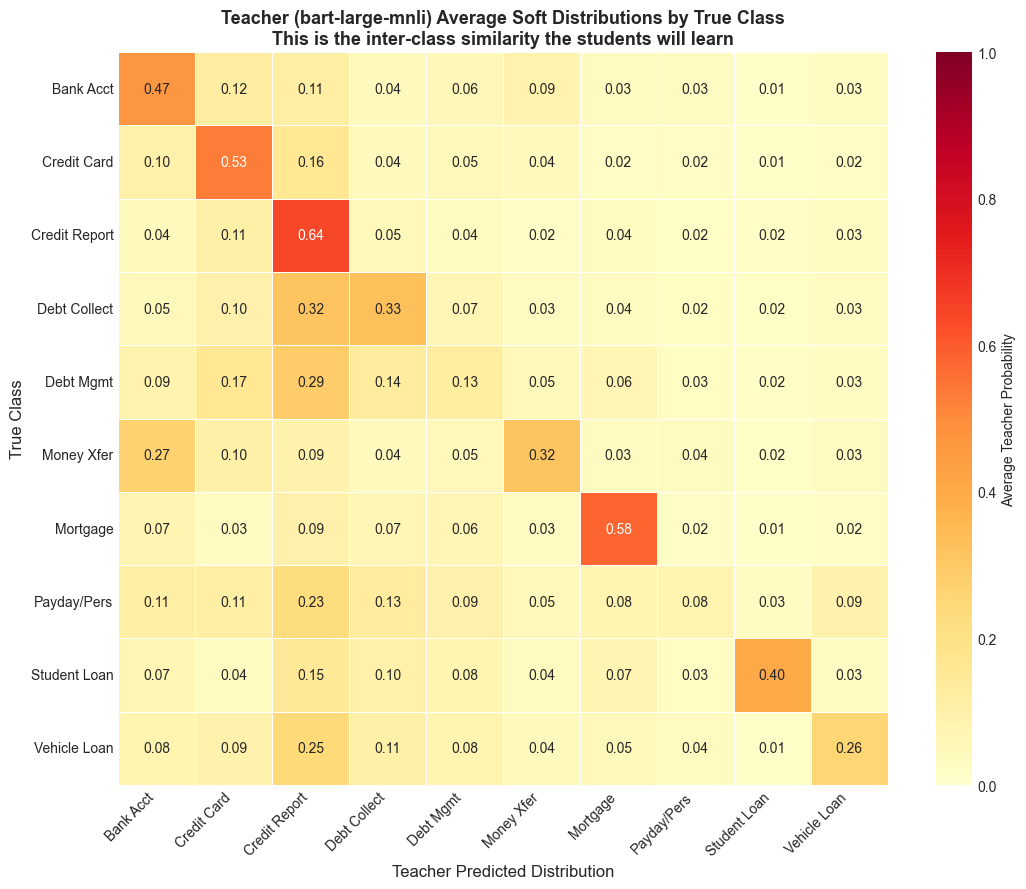

Saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\reports\figures\nb06c\teacher_soft_distributions.png


In [16]:
# ── Visualise: teacher confusion patterns ──
teacher_cm = np.zeros((n_classes, n_classes))
for i in range(len(labels_100k)):
    true_cls = labels_100k[i]
    teacher_cm[true_cls] += teacher_probs[i]

# Normalise by class count
for i in range(n_classes):
    count = (np.array(labels_100k) == i).sum()
    if count > 0:
        teacher_cm[i] /= count

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    teacher_cm, annot=True, fmt=".2f",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    cmap="YlOrRd", ax=ax, linewidths=0.5, linecolor="white",
    vmin=0, vmax=1.0,
    cbar_kws={"label": "Average Teacher Probability"},
)
ax.set_xlabel("Teacher Predicted Distribution", fontsize=12)
ax.set_ylabel("True Class", fontsize=12)
ax.set_title(
    f"Teacher (bart-large-mnli) Average Soft Distributions by True Class\n"
    f"This is the inter-class similarity the students will learn",
    fontsize=13, fontweight="bold",
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

fig_dir = ROOT / "reports" / "figures" / "nb06c"
fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / "teacher_soft_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_dir / 'teacher_soft_distributions.png'}")

## 8 · Cleanup & Summary

In [18]:
del TEACHER_MODEL
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("✓ Teacher model unloaded, GPU memory released.")

✓ Teacher model unloaded, GPU memory released.


In [24]:
# ── Summary ──
print(f"\n{'═'*70}")
print(f"  NB07 — Teacher Inference COMPLETE")
print(f"{'═'*70}")

# Use the config constant from cell 2, not the deleted model variable
teacher_model_name = "facebook/bart-large-mnli"

print(f"\n  Teacher:      {teacher_model_name}")
print(f"  Samples:      {len(teacher_probs):,}")
print(f"  Failures:     {len(failed_indices):,} ({len(failed_indices)/len(teacher_probs):.1%})")

teacher_preds = teacher_probs.argmax(axis=1)
teacher_acc = (teacher_preds == np.array(labels_100k)).mean()

print(f"  Teacher acc:  {teacher_acc:.4f}")
print(f"  Output:       {OUTPUT_DIR / 'teacher_probs.npy'}")
print(f"  Shape:        {teacher_probs.shape}")
print(f"\n{'═'*70}")



══════════════════════════════════════════════════════════════════════
  NB07 — Teacher Inference COMPLETE
══════════════════════════════════════════════════════════════════════

  Teacher:      facebook/bart-large-mnli
  Samples:      25,000
  Failures:     0 (0.0%)
  Teacher acc:  0.7250
  Output:       C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\distillation\teacher_probs.npy
  Shape:        (25000, 10)

══════════════════════════════════════════════════════════════════════
